# Ship detection in Sentinel-1 SAR imagery: Busan and the Korea Strait

This notebook runs the `sarship` pipeline on one Sentinel-1B scene acquired at
21:24 UTC on 4 June 2021 (06:24 KST on 5 June), covering Busan and the
approaches to the Korea Strait, one of the busiest shipping lanes in East Asia.

```
raw GRD (DN) ─► radiometric calibration ─► land mask ─► CFAR ─► clustering ─► GeoJSON
               σ⁰ = DN² / A²              Natural Earth   K-dist.   size / shape
               (+ thermal noise LUT)      + 500 m buffer  clutter   filters
```

Everything is read directly from the public
[Sentinel-1 bucket on AWS](https://registry.opendata.aws/sentinel-1/): only the
annotation XML and the image tiles covering the area of interest are
downloaded (HTTP range requests on a tiled GeoTIFF).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

from sarship import S1Product, ShipDetector, DetectorConfig
from sarship import cfar, viz
from sarship.landmask import land_mask
from sarship.synthetic import k_clutter

FIG = Path("../docs/figures")
FIG.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10})

KEY = "GRD/2021/6/4/IW/DV/S1B_IW_GRDH_1SDV_20210604T212406_20210604T212439_027212_034029_2B33"
BBOX = (128.9, 34.75, 129.45, 35.2)   # lon_min, lat_min, lon_max, lat_max
product = S1Product.from_aws(KEY)
ann = product.annotation("vv")
print(product)
print(f"{ann.mission} {ann.mode} {ann.pass_direction}, {ann.n_lines} x {ann.n_samples} px, "
      f"{ann.range_spacing:.0f} m spacing, polarisations {product.polarisations}")

S1Product('S1B_IW_GRDH_1SDV_20210604T212406_20210604T212439_027212_034029_2B33')
S1B IW Descending, 22223 x 26024 px, 10 m spacing, polarisations ['vh', 'vv']


## 1. Scene and area of interest

The geolocation grid in the annotation (a few hundred tie points) is
interpolated with a bicubic spline for image → map, and inverted
numerically for map → image. The round-trip error is below 0.2 px.

PixelWindow(row0=8990, row1=14687, col0=10773, col1=16593) (5697, 5820)


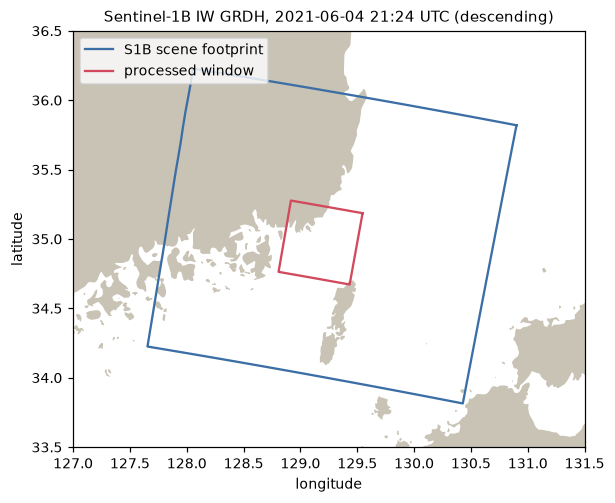

In [2]:
from sarship.landmask import load_land

window = product.window_from_bbox(*BBOX)
tree, land_geoms = load_land()
fig, ax = plt.subplots(figsize=(6, 5.5))
for i in tree.query(__import__("shapely").box(127, 33.5, 131.5, 36.5)):
    g = land_geoms[i]
    for poly in getattr(g, "geoms", [g]):
        ax.fill(*poly.exterior.xy, color="#c9c3b5", lw=0)
scene = ann.geo.footprint()
aoi = ann.geo.footprint((window.row0, window.row1, window.col0, window.col1))
ax.plot(*scene.T, color="#3b6ea5", lw=1.5, label="S1B scene footprint")
ax.plot(*aoi.T, color="#d1495b", lw=1.5, label="processed window")
ax.set_xlim(127, 131.5); ax.set_ylim(33.5, 36.5); ax.set_aspect(1 / np.cos(np.deg2rad(35)))
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.legend(loc="upper left")
ax.set_title("Sentinel-1B IW GRDH, 2021-06-04 21:24 UTC (descending)")
fig.savefig(FIG / "scene_footprint.png", bbox_inches="tight")
print(window, window.shape)

## 2. Radiometric calibration and thermal noise

GRD pixels are digital numbers. Calibrated backscatter is

$$\sigma^0 = \frac{DN^2 - N}{A_\sigma^2}$$

where $A_\sigma$ is the calibration LUT and $N$ the thermal noise estimate
(range LUT × azimuth LUT per sub-swath). $N / A_\sigma^2$ is the
noise-equivalent sigma zero (NESZ), the backscatter level the sensor noise
alone would produce. Noise matters mostly in cross-pol (VH): on this calm
morning the sea VH return is below the NESZ, so raw VH over the sea is
essentially noise, while ships stand far above it.

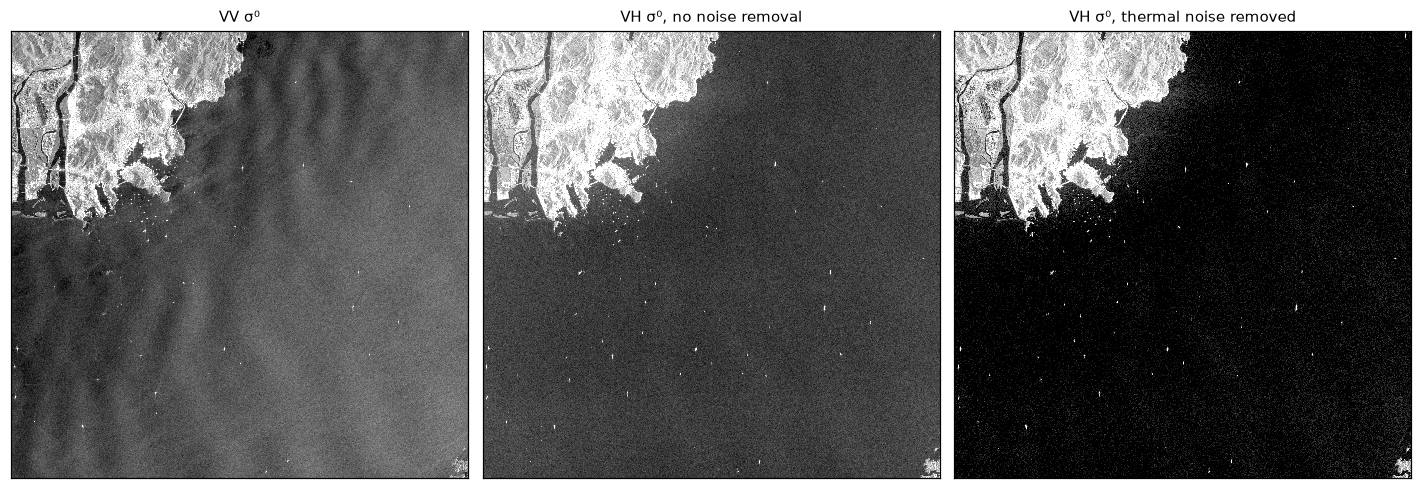

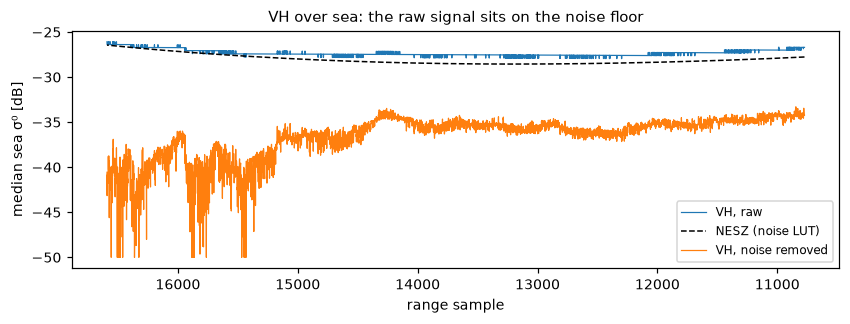

In [3]:
vv = product.read_sigma0("vv", window, denoise=False)
vh_raw = product.read_sigma0("vh", window, denoise=False)
vh_dn = product.read_sigma0("vh", window, denoise=True)
land = land_mask(ann.geo, window, buffer_px=50)
# Images are shown north-up, east-right; on this descending pass that means
# mirroring the columns (range increases westward).
sea = np.isfinite(vv) & ~land

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, img, title, lim in [(axes[0], vv, "VV σ⁰", (-25, 0)),
                            (axes[1], vh_raw, "VH σ⁰, no noise removal", (-32, -12)),
                            (axes[2], vh_dn, "VH σ⁰, thermal noise removed", (-32, -12))]:
    viz.show_sigma0(ax, img, *lim, step=4)
    viz.orient_north_up(ax, window, ann.geo)
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG / "calibration.png", bbox_inches="tight")

cols = window.cols
mid = np.array([(window.row0 + window.row1) / 2])
nesz = (product.noise("vh").interpolate(mid, cols)
        / product.calibration("vh").interpolate(mid, cols) ** 2)[0]
prof = lambda img: 10 * np.log10(np.nanmedian(np.where(sea, img, np.nan), axis=0))
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(cols, prof(vh_raw), lw=0.8, label="VH, raw")
ax.plot(cols, 10 * np.log10(nesz), "k--", lw=1, label="NESZ (noise LUT)")
ax.plot(cols, prof(vh_dn), lw=0.8, label="VH, noise removed")
ax.set_xlabel("range sample"); ax.set_ylabel("median sea σ⁰ [dB]")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("VH over sea: the raw signal sits on the noise floor")
ax.invert_xaxis()  # west (far range) on the left, matching the images
fig.savefig(FIG / "noise_profile.png", bbox_inches="tight")

## 3. Land mask

**Coastline database.** Natural Earth 1:10m land and minor-island polygons
are clipped to the window, mapped into (line, pixel) with the inverse
geolocation model, rasterised, and dilated by 500 m because the coastline is
only accurate to a few hundred metres.

**Image-based refinement.** The database has none of Busan's reclaimed port
land, piers, breakwaters or bridges, and these are exactly the bright,
structured targets a CFAR fires on. The image is smoothed (110 m box, in dB)
and thresholded with Otsu's method; bright regions that touch the coastline
mask, or are larger than 0.25 km², are added to it. Isolated ships are far
smaller and stay in the sea.

masked: 16.3% -> 16.5% of the window


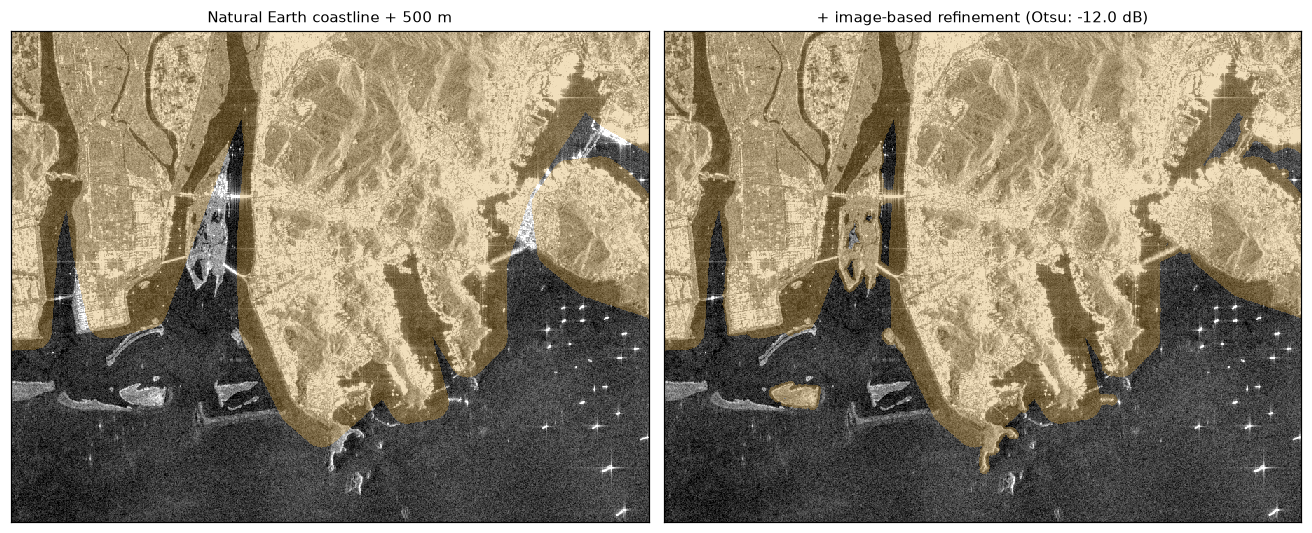

In [4]:
from sarship.landmask import refine_land_mask

land_ref, landlike, thr = refine_land_mask(vv, land)
# Zoom on the port: Yeongdo, the North/South ports and Gamcheon.
port = (slice(1300, 2700), slice(4000, 5820))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, m, title in [(axes[0], land, "Natural Earth coastline + 500 m"),
                     (axes[1], land_ref, f"+ image-based refinement (Otsu: {thr:.1f} dB)")]:
    viz.show_sigma0(ax, vv[port], step=2)
    viz.show_mask(ax, m[port], step=2)
    if viz.north_up_flips(window, ann.geo)[1]:
        ax.invert_xaxis()
    ax.set_title(title)
print(f"masked: {land.mean():.1%} -> {land_ref.mean():.1%} of the window")
fig.tight_layout()
fig.savefig(FIG / "land_mask.png", bbox_inches="tight")

## 4. What does sea clutter look like?

A CFAR threshold is only as good as its clutter model. The textbook choice
for multi-look intensity is the gamma distribution with $L$ looks
(ENL ≈ 4.4 for IW GRDH). Real sea clutter is spikier: the backscatter is
modulated by waves and wind, which the **K distribution** models as gamma
speckle times a gamma-distributed texture with shape $\nu$
(smaller $\nu$ = heavier tail).

Below, every sea pixel is divided by the mean of its CFAR background ring, and
the empirical exceedance probability is compared with both models. Ships
would otherwise dominate the far tail, so pixels in target-sized clusters
(≥ 4 px exceeding a K-CFAR at $10^{-7}$, dilated by 100 m) are left out;
isolated bright clutter pixels stay in. $\nu$ is
estimated by log-cumulants, $\mathrm{Var}[\ln I] = \psi_1(L) + \psi_1(\nu)$,
which is barely affected by the ships themselves.

estimated K texture shape nu = 25.98


Pfa=1e-05: gamma threshold 4.4x local mean (measured 1.1e-04), K threshold 5.5x (measured 3.9e-05)
Pfa=1e-07: gamma threshold 5.7x local mean (measured 3.4e-05), K threshold 7.4x (measured 8.6e-06)


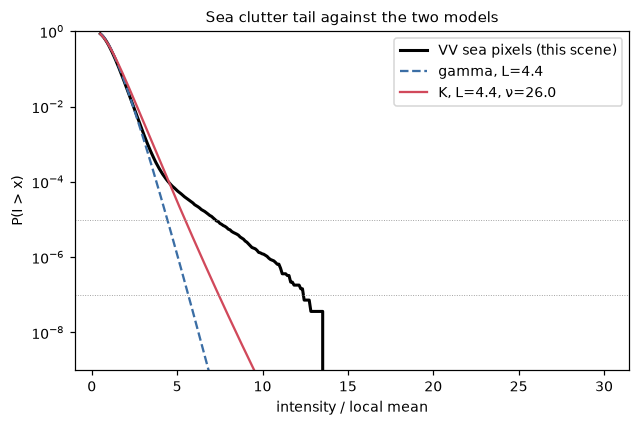

In [5]:
from scipy import ndimage

ENL = 4.4
sea = np.isfinite(vv) & ~land_ref
prelim = cfar.ca_cfar_k(vv, 1e-7, ENL, valid=sea).detections
lab, _ = ndimage.label(prelim, structure=np.ones((3, 3)))
targets = np.isin(lab, np.flatnonzero(np.bincount(lab.ravel()) >= 4)[1:])
targets = ndimage.binary_dilation(targets, iterations=10)
st = cfar.ring_stats(vv, sea, guard=20, background=50)
ok = sea & ~targets & (st.count >= 200)
ratio = (vv[ok] / st.mean[ok]).astype(np.float64)
nu = cfar.k_shape_from_log_cumulants(ratio, ENL)
print(f"estimated K texture shape nu = {nu:.2f}")

t = np.linspace(0.5, 30, 300)
emp = np.array([(ratio > x).mean() for x in t])
gam = stats.gamma.sf(t, ENL, scale=1 / ENL)
kdist = np.array([cfar.k_sf(x, ENL, nu) for x in t])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.semilogy(t, emp, "k", lw=2, label="VV sea pixels (this scene)")
ax.semilogy(t, gam, "--", color="#3b6ea5", label=f"gamma, L={ENL}")
ax.semilogy(t, kdist, "-", color="#d1495b", label=f"K, L={ENL}, ν={nu:.1f}")
for pfa in (1e-5, 1e-7):
    ax.axhline(pfa, color="0.6", lw=0.6, ls=":")
ax.set_ylim(1e-9, 1); ax.set_xlabel("intensity / local mean"); ax.set_ylabel("P(I > x)")
ax.set_title("Sea clutter tail against the two models")
ax.legend()
fig.savefig(FIG / "clutter_tail.png", bbox_inches="tight")
for pfa in (1e-5, 1e-7):
    a_g = stats.gamma.isf(pfa, ENL, scale=1 / ENL)
    a_k = cfar.k_threshold_multiplier(pfa, ENL, nu)
    print(f"Pfa={pfa:g}: gamma threshold {a_g:.1f}x local mean "
          f"(measured {(ratio > a_g).mean():.1e}), "
          f"K threshold {a_k:.1f}x (measured {(ratio > a_k).mean():.1e})")

**Reading the plot.** Gamma speckle underestimates the tail from about
three times the local mean onwards. The K model with the fitted $\nu$
follows the body of the distribution down to ~$10^{-4}$ and sets a
threshold about 30% higher at $10^{-7}$, cutting the measured exceedance
four-fold. Beyond that, the measured tail is heavier than either model (at
the $10^{-7}$ K threshold, ~$10^{-5}$ of target-free sea pixels still
exceed it), and it stays so when the exclusion zone around ships is widened
to 600 m. So it is not ship sidelobes; the likely culprits
are unresolved point targets (buoys, fishing gear, boats smaller than
4 px). On real data the per-pixel false-alarm rate is therefore above the
design value, which is why the pipeline does not stop at the threshold: the
cluster size, peak brightness and open-sea tests do the rest.

## 5. Validating the detectors on synthetic clutter

The real scene has no ground truth, so false-alarm behaviour is measured on
simulated K clutter with the $\nu$ just estimated, where every detection is
by construction false. A detector is CFAR if the measured rate follows the
design $P_{fa}$ (dashed diagonal).

two-parameter (Gaussian)   at Pfa=1e-4: 4.9e-03  (49x design)
CA-CFAR, gamma             at Pfa=1e-4: 6.2e-04  (6x design)
CA-CFAR, K                 at Pfa=1e-4: 1.0e-04  (1x design)


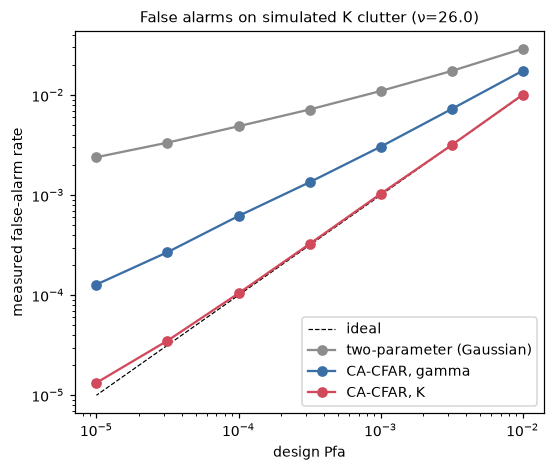

In [6]:
sim = k_clutter((1500, 1500), enl=ENL, nu=nu, rng=0)
pfas = np.logspace(-2, -5, 7)
rates = {"two-parameter (Gaussian)": [], "CA-CFAR, gamma": [], "CA-CFAR, K": []}
for pfa in pfas:
    kw = dict(guard=5, background=25)
    for name, res in [
        ("two-parameter (Gaussian)", cfar.two_parameter_cfar(sim, pfa, **kw)),
        ("CA-CFAR, gamma", cfar.ca_cfar_gamma(sim, pfa, ENL, **kw)),
        ("CA-CFAR, K", cfar.ca_cfar_k(sim, pfa, ENL, **kw)),
    ]:
        rates[name].append(res.detections[res.stats.count >= 200].mean())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.loglog(pfas, pfas, "k--", lw=0.8, label="ideal")
for (name, r), c in zip(rates.items(), ["#8c8c8c", "#3b6ea5", "#d1495b"]):
    ax.loglog(pfas, np.maximum(r, 1e-7), "o-", color=c, label=name)
ax.set_xlabel("design Pfa"); ax.set_ylabel("measured false-alarm rate")
ax.set_title(f"False alarms on simulated K clutter (ν={nu:.1f})")
ax.legend()
fig.savefig(FIG / "pfa_validation.png", bbox_inches="tight")
for name, r in rates.items():
    print(f"{name:26s} at Pfa=1e-4: {r[4]:.1e}  ({r[4] / pfas[4]:.0f}x design)")

## 6. Detection over Busan

K-distribution CA-CFAR at $P_{fa}=10^{-7}$ on VV (guard 200 m, background
500 m), followed by connected-component clustering. Clusters are kept if
they are at least 4 px, shorter than 450 m, and peak above −5 dB.

Length and width come from the second moments of the pixels within 15 dB
of the cluster's peak, so the sidelobe cross around bright ships does not
count as hull.

Weak clusters (peak below +5 dB) must also sit in open sea: at least 300 m
from the land mask, and with almost no land-like pixels within 400 m. Next to
the coast and around the Nakdong estuary sand bars, the clutter is rocks,
surf and sand, not the sea clutter the threshold was designed for.

(The pipeline estimates $\nu$ without removing ships first, which gives a
slightly heavier-tailed, more conservative value than in section 4.)

126 detections, K shape nu=20.97, 74 weak coastal detections rejected


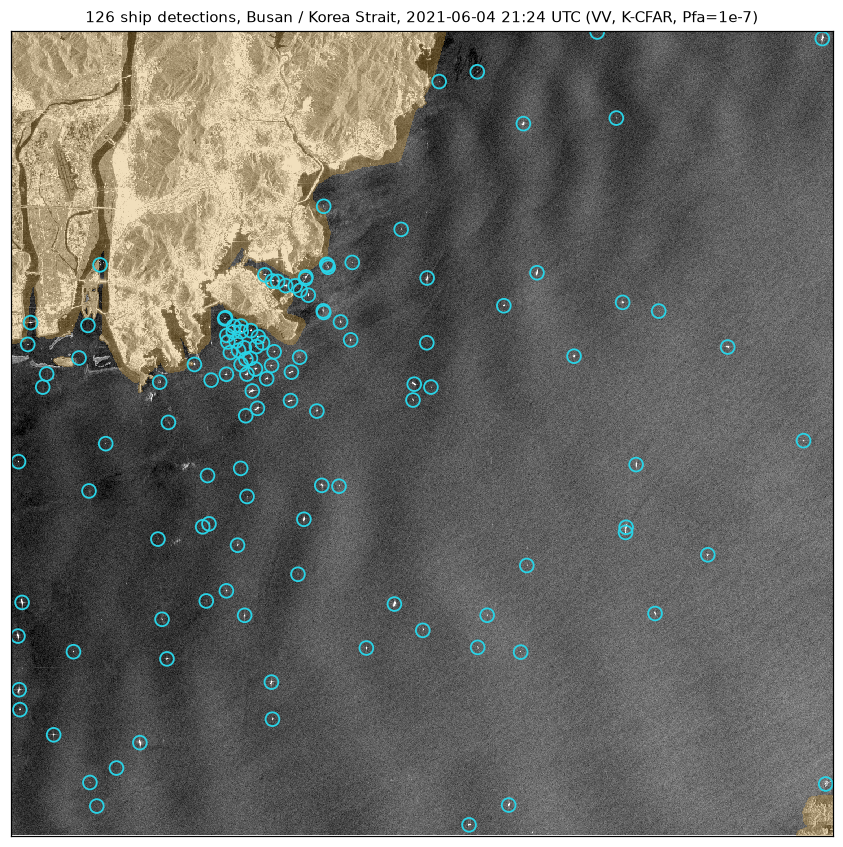

In [7]:
cfg = DetectorConfig(pol="vv", method="k", pfa=1e-7)
result = ShipDetector(cfg).run(product, window=window)
print(f"{len(result.detections)} detections, K shape nu={result.nu:.2f}, "
      f"{result.extra['weak_rejected']} weak coastal detections rejected")
result.save_geojson("../docs/busan_detections.geojson")

fig, ax = plt.subplots(figsize=(10, 9.5))
viz.show_sigma0(ax, result.sigma0, step=4)
viz.show_mask(ax, result.land, step=4)
viz.plot_detections(ax, result, step=4, size=9)
flip_ud, flip_lr = viz.orient_north_up(ax, window, ann.geo)
ax.set_title(f"{len(result.detections)} ship detections, Busan / Korea Strait, "
             "2021-06-04 21:24 UTC (VV, K-CFAR, Pfa=1e-7)")
fig.savefig(FIG / "busan_detections.png", bbox_inches="tight", dpi=130)

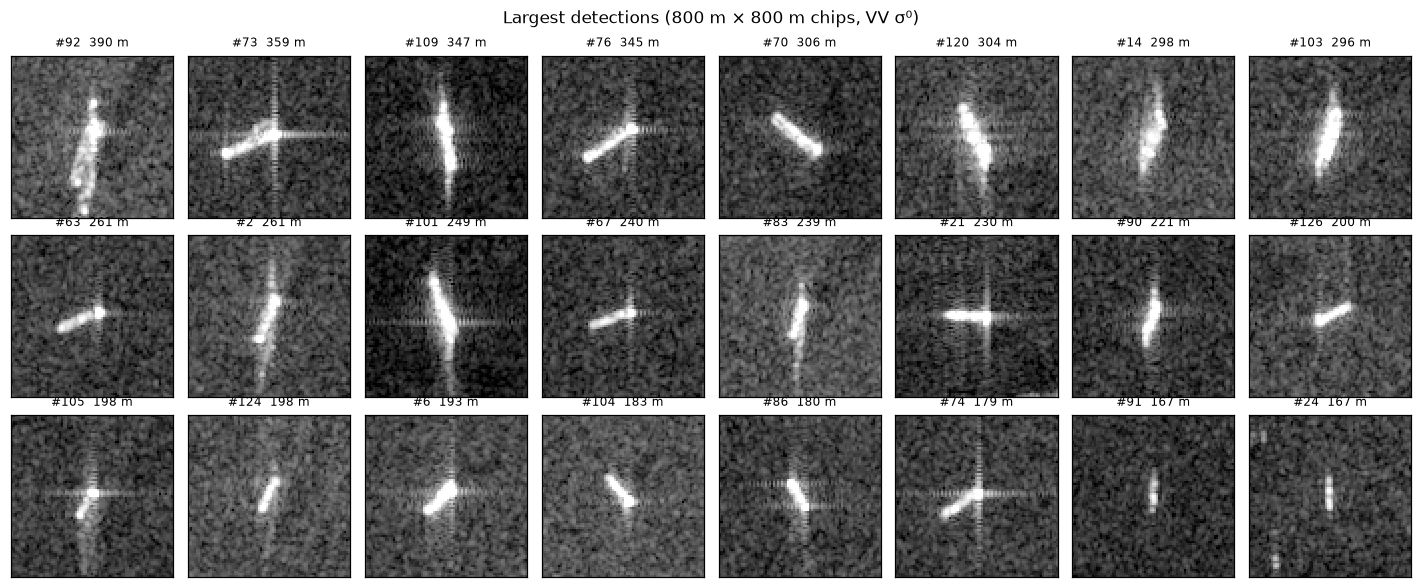

In [8]:
largest = sorted(result.detections, key=lambda d: -d.length_m)[:24]
fig, axes = plt.subplots(3, 8, figsize=(13, 5.4))
for ax, d in zip(axes.flat, largest):
    c = viz.chip(result, d, half=40)
    viz.show_sigma0(ax, c[::-1] if flip_ud else c, -25, 5)
    if flip_lr:
        ax.invert_xaxis()
    ax.set_title(f"#{d.id}  {d.length_m:.0f} m", fontsize=8)
for ax in axes.flat[len(largest):]:
    ax.axis("off")
fig.suptitle("Largest detections (800 m × 800 m chips, VV σ⁰)")
fig.tight_layout()
fig.savefig(FIG / "detection_chips.png", bbox_inches="tight")

Top 10 by length:
  # 92  34.8924N 129.3191E    390 m x  72 m  peak  17.9 dB
  # 73  35.0209N 129.0523E    359 m x  41 m  peak  25.9 dB
  #109  34.8900N 128.8400E    347 m x  60 m  peak  13.6 dB
  # 76  35.0093N 129.0539E    345 m x  39 m  peak  18.1 dB
  # 70  35.0074N 129.1774E    306 m x  68 m  peak   9.4 dB
  #120  34.8086N 128.9184E    304 m x  60 m  peak  19.1 dB
  # 14  35.0649N 129.2867E    298 m x  82 m  peak  11.3 dB
  #103  34.8691N 129.1316E    296 m x  74 m  peak  14.1 dB
  # 63  35.0287N 129.0849E    261 m x  43 m  peak  14.5 dB
  #  2  35.1826N 129.5379E    261 m x  49 m  peak  14.7 dB


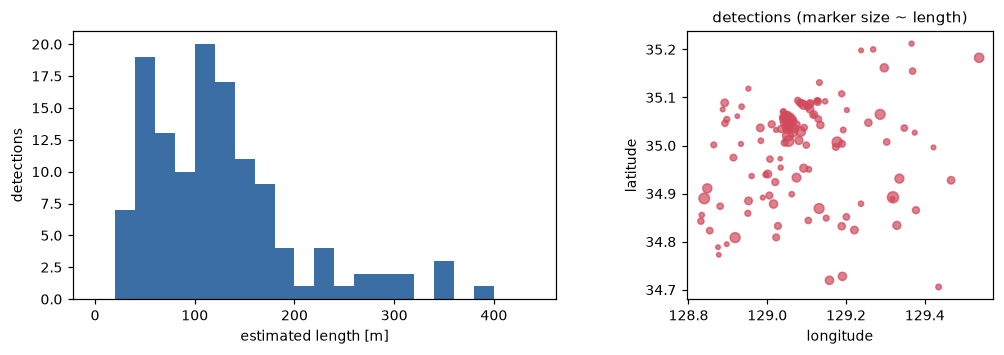

In [9]:
lengths = np.array([d.length_m for d in result.detections])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].hist(lengths, bins=np.arange(0, 460, 20), color="#3b6ea5")
ax[0].set_xlabel("estimated length [m]"); ax[0].set_ylabel("detections")
ax[1].scatter([d.lon for d in result.detections], [d.lat for d in result.detections],
              s=4 + lengths / 8, c="#d1495b", alpha=0.7)
ax[1].set_xlabel("longitude"); ax[1].set_ylabel("latitude")
ax[1].set_aspect(1 / np.cos(np.deg2rad(35)))
ax[1].set_title("detections (marker size ~ length)")
fig.tight_layout()
fig.savefig(FIG / "detection_stats.png", bbox_inches="tight")
print("Top 10 by length:")
for d in largest[:10]:
    print(f"  #{d.id:3d}  {d.lat:.4f}N {d.lon:.4f}E  {d.length_m:5.0f} m x {d.width_m:3.0f} m  "
          f"peak {d.peak_db:5.1f} dB")

## 7. Cross-check: VV against VH

With no AIS reference at hand, one independent check is to detect again in
cross-polarisation. Ships are strong depolarisers while the sea VH return is
near the noise floor, so VH usually has better ship/sea contrast but also
misses small, weak targets. Detections within 100 m of each other are paired.

In [10]:
# VH is ~10 dB darker than VV, so the brightness gates move down accordingly.
vh_cfg = DetectorConfig(pol="vh", method="k", pfa=1e-7, min_peak_db=-15, weak_peak_db=-5)
res_vh = ShipDetector(vh_cfg).run(product, window=window)
a = np.array([[d.row, d.col] for d in result.detections])
b = np.array([[d.row, d.col] for d in res_vh.detections])
dist = np.hypot(a[:, None, 0] - b[None, :, 0], a[:, None, 1] - b[None, :, 1])
both = (dist.min(axis=1) <= 10)
print(f"VV: {len(a)}   VH: {len(b)}   in both: {both.sum()}   "
      f"VV only: {(~both).sum()}   VH only: {(dist.min(axis=0) > 10).sum()}")
print(f"median length, confirmed in VH: {np.median(lengths[both]):.0f} m; "
      f"VV only: {np.median(lengths[~both]):.0f} m")

VV: 126   VH: 131   in both: 98   VV only: 28   VH only: 33
median length, confirmed in VH: 124 m; VV only: 72 m


## 8. Limitations and next steps

* **No ground truth.** The natural reference is AIS; matching detections to
  AIS positions interpolated to the acquisition time would give detection
  and false-alarm rates on real data.
* **Azimuth ambiguities.** Very bright targets produce ghost copies displaced
  in azimuth by a fixed, computable offset; these are not filtered.
* **Coastline.** Natural Earth is coarse. A higher-resolution coastline (OSM
  land polygons) would allow a smaller buffer and recover ships moored near
  breakwaters.
* **Moving-ship offset.** Moving targets are displaced in azimuth in proportion
  to their radial velocity (the "train off the track" effect), up to hundreds
  of metres.
* **Target size.** Size is measured on pixels within 15 dB of each target's
  peak, which keeps the sidelobe cross of bright ships out (median width of
  ships over 200 m drops from ~90 m to ~50 m). At ~20 m resolution small
  targets are still inflated by the impulse response; a proper estimate would
  fit an oriented rectangle convolved with the point spread function.
* **Global ν.** One texture shape is used for the whole window; estimating it
  per tile would adapt to wind fronts and sheltered water.